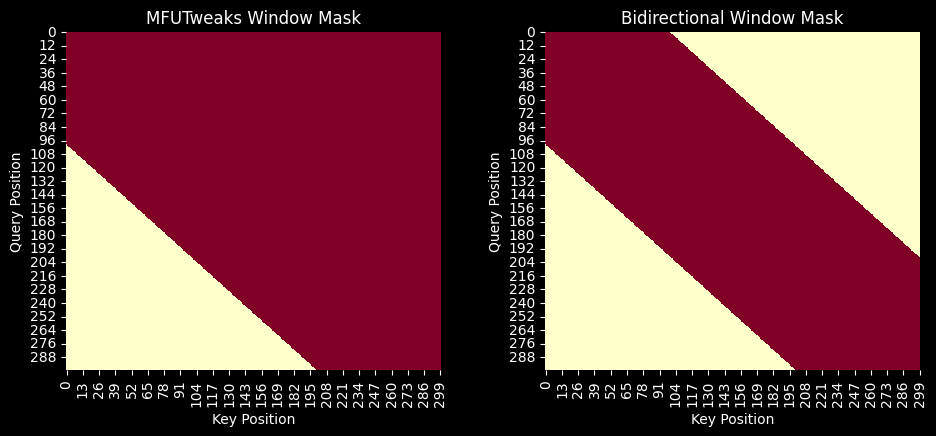

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def compare_mask(seq_len, attn_windowsize=1024):

    row_idx = np.arange(seq_len)
    col_idx = np.arange(seq_len)

    def create_MFUTweaks_window_mask(q_idx, kv_idx):
        return q_idx - kv_idx < attn_windowsize

    def create_bidirectional_window_mask(q_idx, kv_idx):
        return abs(q_idx - kv_idx) < attn_windowsize

    # Masks to visualise
    MFUTweaks_mask = create_MFUTweaks_window_mask(row_idx[:, None], col_idx[None, :])
    bidirectional_mask = create_bidirectional_window_mask(row_idx[:, None], col_idx[None, :])

    # Visualisation
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))

    sns.heatmap(MFUTweaks_mask, ax=axes[0], cmap='YlOrRd', cbar=False)
    axes[0].set_title('MFUTweaks Window Mask')
    axes[0].set_xlabel('Key Position')
    axes[0].set_ylabel('Query Position')

    sns.heatmap(bidirectional_mask, ax=axes[1], cmap='YlOrRd', cbar=False)
    axes[1].set_title('Bidirectional Window Mask')
    axes[1].set_xlabel('Key Position')
    axes[1].set_ylabel('Query Position')

    plt.tight_layout(pad=3.0)
    plt.show()

# Example call
compare_mask(seq_len=300, attn_windowsize=100)
